# 04 Evaluation and Report-Ready Results

This notebook creates report-ready tables and figures for BAB IV.

It covers:
- graph feature ablation,
- four-model comparison,
- final node2vec model performance,
- threshold evaluation,
- confusion matrix,
- Top-K evaluation,
- class imbalance and operational interpretation.

In [1]:
from pathlib import Path
import sys

# Works when launched from repository root or from notebooks/.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_table(name: str, fallback_rows=None) -> pd.DataFrame:
    """Read a report CSV from common locations; fallback rows make the notebook displayable."""
    candidate_paths = [
        TABLES_DIR / name,
        PROJECT_ROOT / name,
        Path("/mnt/data") / name,  # useful only in ChatGPT sandbox
    ]
    for path in candidate_paths:
        if path.exists():
            print(f"Loaded {name} from {path}")
            return pd.read_csv(path)
    if fallback_rows is not None:
        print(f"Using embedded fallback rows for {name}")
        return pd.DataFrame(fallback_rows)
    raise FileNotFoundError("Could not find " + name + " in:\n" + "\n".join(str(p) for p in candidate_paths))

PROJECT_ROOT: /home/acer/dev/aml-graph-dm


## 1. Load result artifacts

The notebook reads CSV files from `reports/tables/`. If the files are not available, embedded fallback rows based on the latest project outputs are used so the notebook remains readable.

In [2]:
four_model = read_table("four_model_comparison_temporal_graph_final.csv", [
    {"model":"lightgbm","val_pr_auc":0.035802,"test_pr_auc":0.081038,"test_f1":0.154743,"test_precision":0.109683,"test_recall":0.262637,"test_alert_count":2179},
    {"model":"xgboost","val_pr_auc":0.032368,"test_pr_auc":0.053348,"test_f1":0.108758,"test_precision":0.063674,"test_recall":0.372527,"test_alert_count":5324},
    {"model":"random_forest","val_pr_auc":0.023960,"test_pr_auc":0.042708,"test_f1":0.092769,"test_precision":0.050570,"test_recall":0.560440,"test_alert_count":10085},
    {"model":"logistic_regression","val_pr_auc":0.006419,"test_pr_auc":0.133309,"test_f1":0.027266,"test_precision":0.013825,"test_recall":0.981319,"test_alert_count":64592},
])

node2vec_metrics = read_table("lgbm_node2vec_metrics_final.csv", [
    {"model":"lightgbm_node2vec","feature_set":"raw_plus_advanced_graph_plus_node2vec","test_pr_auc":0.117686,"test_f1":0.181235,"test_precision":0.123315,"test_recall":0.341758,"test_alert_count":2522,"feature_count":145},
])

threshold_eval = read_table("final_threshold_evaluation_node2vec_final.csv", [
    {"setting":"default_threshold_0.5","threshold":0.50,"pr_auc":0.117686,"f1":0.181235,"precision":0.123315,"recall":0.341758,"alert_count":2522},
    {"setting":"tuned_threshold_validation","threshold":0.98,"pr_auc":0.117686,"f1":0.147059,"precision":0.187713,"recall":0.120879,"alert_count":586},
])

topk_eval = read_table("top_k_evaluation_node2vec_final.csv", [
    {"k":50,"precision_at_k":0.380,"recall_at_k":0.020879},
    {"k":100,"precision_at_k":0.320,"recall_at_k":0.035165},
    {"k":200,"precision_at_k":0.220,"recall_at_k":0.048352},
    {"k":500,"precision_at_k":0.196,"recall_at_k":0.107692},
    {"k":1000,"precision_at_k":0.161,"recall_at_k":0.176923},
])

confusion_matrix_df = read_table("confusion_matrix_tuned_node2vec_final.csv", [
    {"Unnamed: 0":"actual_normal","predicted_normal":398614,"predicted_laundering":476},
    {"Unnamed: 0":"actual_laundering","predicted_normal":800,"predicted_laundering":110},
])

Loaded four_model_comparison_temporal_graph_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/four_model_comparison_temporal_graph_final.csv
Loaded lgbm_node2vec_metrics_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/lgbm_node2vec_metrics_final.csv
Loaded final_threshold_evaluation_node2vec_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/final_threshold_evaluation_node2vec_final.csv
Loaded top_k_evaluation_node2vec_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/top_k_evaluation_node2vec_final.csv
Loaded confusion_matrix_tuned_node2vec_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/confusion_matrix_tuned_node2vec_final.csv


## 2. Class imbalance visualization

This figure supports the explanation that accuracy is not meaningful for AML. The positive class is very rare, so the evaluation focuses on PR-AUC, minority-class F1, precision, recall, and Top-K alert quality.

,class,count,dataset
0,normal,5073168,Full HI-Small
1,laundering,5177,Full HI-Small
2,normal,1998502,2M experiment
3,laundering,1498,2M experiment


Saved: /home/acer/dev/aml-graph-dm/reports/tables/class_imbalance_summary_final.csv


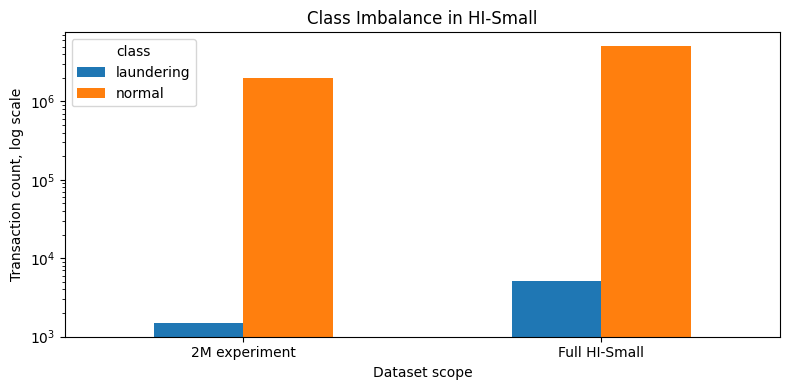

Saved: /home/acer/dev/aml-graph-dm/reports/figures/class_imbalance_log_scale.png


In [3]:
imbalance_df = pd.DataFrame([
    {"class":"normal", "count":5_073_168, "dataset":"Full HI-Small"},
    {"class":"laundering", "count":5_177, "dataset":"Full HI-Small"},
    {"class":"normal", "count":1_998_502, "dataset":"2M experiment"},
    {"class":"laundering", "count":1_498, "dataset":"2M experiment"},
])

display(imbalance_df)
imbalance_df.to_csv(TABLES_DIR / "class_imbalance_summary_final.csv", index=False)
print("Saved:", TABLES_DIR / "class_imbalance_summary_final.csv")

pivot = imbalance_df.pivot(index="dataset", columns="class", values="count")
ax = pivot.plot(kind="bar", figsize=(8, 4), logy=True)
ax.set_title("Class Imbalance in HI-Small")
ax.set_xlabel("Dataset scope")
ax.set_ylabel("Transaction count, log scale")
plt.xticks(rotation=0)
plt.tight_layout()

out_path = FIGURES_DIR / "class_imbalance_log_scale.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## 2. Feature-set ablation

This answers: **Do graph features improve the model?**

The ablation uses LightGBM to isolate the effect of feature engineering.

In [4]:
ablation_rows = []

# Raw and historical graph from saved final_neg100 result.
try:
    hist = read_table("lgbm_fast_metrics_final_neg100.csv")
    raw_hist = hist.loc[hist["feature_set"].eq("raw")].iloc[0]
    graph_hist = hist.loc[hist["feature_set"].eq("raw_plus_graph")].iloc[0]
    ablation_rows.append({"experiment":"Raw baseline", "test_pr_auc":raw_hist["test_pr_auc"], "test_f1":raw_hist["test_f1"], "precision":raw_hist["test_precision"], "recall":raw_hist["test_recall"]})
    ablation_rows.append({"experiment":"Historical graph", "test_pr_auc":graph_hist["test_pr_auc"], "test_f1":graph_hist["test_f1"], "precision":graph_hist["test_precision"], "recall":graph_hist["test_recall"]})
except Exception:
    ablation_rows.extend([
        {"experiment":"Raw baseline", "test_pr_auc":0.046563, "test_f1":0.093501, "precision":0.053842, "recall":0.354945},
        {"experiment":"Historical graph", "test_pr_auc":0.073463, "test_f1":0.138097, "precision":0.095002, "recall":0.252747},
    ])

try:
    advanced = read_table("lgbm_fast_metrics_advanced_graph_neg100.csv")
    adv_graph = advanced.loc[advanced["feature_set"].eq("raw_plus_graph")].iloc[0]
    ablation_rows.append({"experiment":"Historical + rolling + advanced graph", "test_pr_auc":adv_graph["test_pr_auc"], "test_f1":adv_graph["test_f1"], "precision":adv_graph["test_precision"], "recall":adv_graph["test_recall"]})
except Exception:
    ablation_rows.append({"experiment":"Historical + rolling + advanced graph", "test_pr_auc":0.095015, "test_f1":0.177289, "precision":0.120378, "recall":0.336264})

try:
    snap = read_table("lgbm_fast_metrics_snapshot_graph_neg100.csv")
    snap_graph = snap.loc[snap["feature_set"].eq("raw_plus_graph")].iloc[0]
    ablation_rows.append({"experiment":"Advanced graph + snapshot PageRank/community", "test_pr_auc":snap_graph["test_pr_auc"], "test_f1":snap_graph["test_f1"], "precision":snap_graph["test_precision"], "recall":snap_graph["test_recall"]})
except Exception:
    ablation_rows.append({"experiment":"Advanced graph + snapshot PageRank/community", "test_pr_auc":0.086253, "test_f1":0.164038, "precision":0.110982, "recall":0.314286})

n2v = node2vec_metrics.iloc[0]
ablation_rows.append({"experiment":"Advanced graph + node2vec", "test_pr_auc":n2v["test_pr_auc"], "test_f1":n2v["test_f1"], "precision":n2v["test_precision"], "recall":n2v["test_recall"]})

ablation = pd.DataFrame(ablation_rows)
display(ablation)
ablation.to_csv(TABLES_DIR / "final_feature_ablation_summary.csv", index=False)
print("Saved:", TABLES_DIR / "final_feature_ablation_summary.csv")

Loaded lgbm_fast_metrics_final_neg100.csv from /home/acer/dev/aml-graph-dm/reports/tables/lgbm_fast_metrics_final_neg100.csv
Loaded lgbm_fast_metrics_advanced_graph_neg100.csv from /home/acer/dev/aml-graph-dm/reports/tables/lgbm_fast_metrics_advanced_graph_neg100.csv
Loaded lgbm_fast_metrics_snapshot_graph_neg100.csv from /home/acer/dev/aml-graph-dm/reports/tables/lgbm_fast_metrics_snapshot_graph_neg100.csv


,experiment,test_pr_auc,test_f1,precision,recall
0,Raw baseline,0.046563,0.093501,0.053842,0.354945
1,Historical graph,0.073463,0.138097,0.095002,0.252747
2,Historical + rolling + advanced graph,0.095015,0.177289,0.120378,0.336264
3,Advanced graph + snapshot PageRank/community,0.086253,0.164038,0.110982,0.314286
4,Advanced graph + node2vec,0.117686,0.181235,0.123315,0.341758


Saved: /home/acer/dev/aml-graph-dm/reports/tables/final_feature_ablation_summary.csv


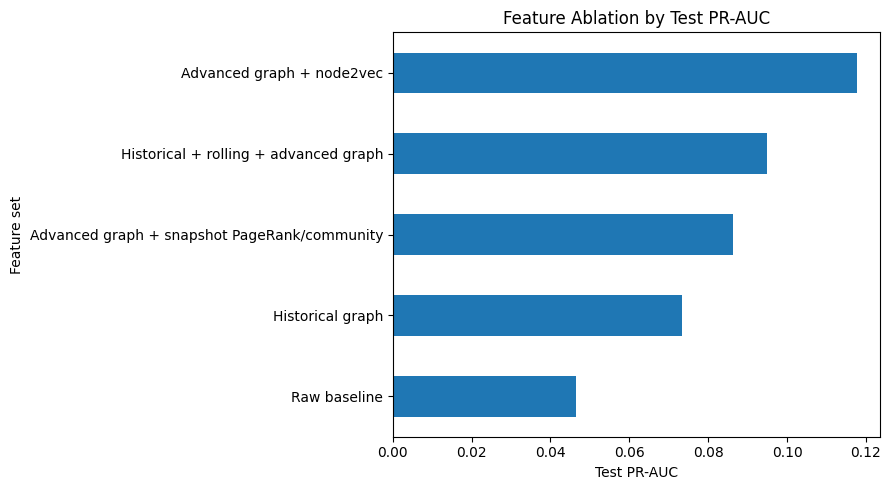

Saved: /home/acer/dev/aml-graph-dm/reports/figures/feature_ablation_pr_auc.png


In [5]:
plot_df = ablation.sort_values("test_pr_auc")
ax = plot_df.plot(kind="barh", x="experiment", y="test_pr_auc", legend=False, figsize=(9, 5))
ax.set_title("Feature Ablation by Test PR-AUC")
ax.set_xlabel("Test PR-AUC")
ax.set_ylabel("Feature set")
plt.tight_layout()

out_path = FIGURES_DIR / "feature_ablation_pr_auc.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## 3. Four-model comparison

This answers: **Which algorithm performs best?**

Model selection uses validation PR-AUC. Logistic Regression has very high recall but produces too many alerts, so it is not operationally preferred.

,model,feature_set,neg_per_pos,feature_count,train_sample_rows,train_sample_pos,train_sample_neg,val_pr_auc,val_f1,val_precision,val_recall,test_pr_auc,test_f1,test_precision,test_recall,test_tp,test_fp,test_tn,test_fn,test_alert_count
0,lightgbm,raw_plus_temporal_graph,100,92,36461,361,36100,0.035802,0.073724,0.041292,0.343612,0.081038,0.154743,0.109683,0.262637,239,1940,397150,671,2179
1,xgboost,raw_plus_temporal_graph,100,92,36461,361,36100,0.032368,0.038728,0.020178,0.480176,0.053348,0.108758,0.063674,0.372527,339,4985,394105,571,5324
2,random_forest,raw_plus_temporal_graph,100,92,36461,361,36100,0.023960,0.024277,0.012399,0.577093,0.042708,0.092769,0.050570,0.560440,510,9575,389515,400,10085
3,logistic_regression,raw_plus_temporal_graph,100,92,36461,361,36100,0.006419,0.006578,0.003301,0.942731,0.133309,0.027266,0.013825,0.981319,893,63699,335391,17,64592


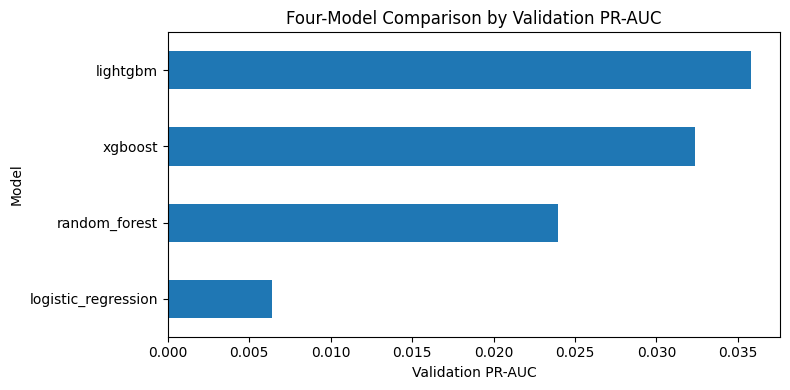

Saved: /home/acer/dev/aml-graph-dm/reports/figures/four_model_validation_pr_auc.png


In [6]:
display(four_model.sort_values("val_pr_auc", ascending=False))

ax = four_model.sort_values("val_pr_auc").plot(kind="barh", x="model", y="val_pr_auc", legend=False, figsize=(8, 4))
ax.set_title("Four-Model Comparison by Validation PR-AUC")
ax.set_xlabel("Validation PR-AUC")
ax.set_ylabel("Model")
plt.tight_layout()

out_path = FIGURES_DIR / "four_model_validation_pr_auc.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## 4. Final node2vec model metrics

This is the final selected model used for the main conclusion.

In [7]:
display(node2vec_metrics)

final_row = node2vec_metrics.iloc[0]
final_summary = pd.DataFrame([
    {"metric":"Test PR-AUC", "value":final_row["test_pr_auc"]},
    {"metric":"F1-score", "value":final_row["test_f1"]},
    {"metric":"Precision", "value":final_row["test_precision"]},
    {"metric":"Recall", "value":final_row["test_recall"]},
    {"metric":"Alert count", "value":final_row["test_alert_count"]},
])
display(final_summary)
final_summary.to_csv(TABLES_DIR / "final_node2vec_summary.csv", index=False)
print("Saved:", TABLES_DIR / "final_node2vec_summary.csv")

,model,feature_set,neg_per_pos,node2vec_dimensions,node2vec_walk_length,node2vec_num_walks,node2vec_max_edges,feature_count,val_pr_auc,val_f1,...,val_recall,test_pr_auc,test_f1,test_precision,test_recall,test_tp,test_fp,test_tn,test_fn,test_alert_count
0,lightgbm_node2vec,raw_plus_advanced_graph_plus_node2vec,100,16,10,5,300000,145,0.040234,0.073801,...,0.30837,0.117686,0.181235,0.123315,0.341758,311,2211,396879,599,2522


,metric,value
0,Test PR-AUC,0.117686
1,F1-score,0.181235
2,Precision,0.123315
3,Recall,0.341758
4,Alert count,2522.000000


Saved: /home/acer/dev/aml-graph-dm/reports/tables/final_node2vec_summary.csv


## 5. Threshold evaluation

The default threshold gives better F1 and recall. The tuned validation threshold is stricter and gives higher precision with fewer alerts.

,setting,threshold,pr_auc,f1,precision,recall,alert_count
0,default_threshold_0.5,0.50,0.117686,0.181235,0.123315,0.341758,2522
1,tuned_threshold_validation,0.98,0.117686,0.147059,0.187713,0.120879,586


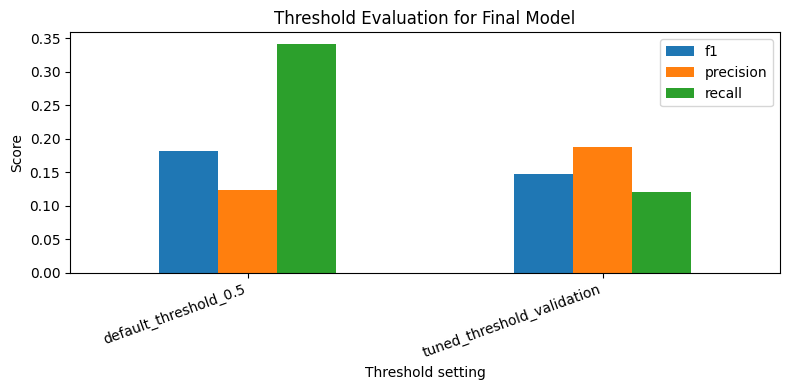

Saved: /home/acer/dev/aml-graph-dm/reports/figures/threshold_evaluation_node2vec.png


In [8]:
display(threshold_eval)

ax = threshold_eval.plot(kind="bar", x="setting", y=["f1", "precision", "recall"], figsize=(8, 4))
ax.set_title("Threshold Evaluation for Final Model")
ax.set_xlabel("Threshold setting")
ax.set_ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

out_path = FIGURES_DIR / "threshold_evaluation_node2vec.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## 6. Top-K evaluation

Top-K is highly relevant for AML because analysts normally review the highest-risk transactions first.

,k,precision_at_k,recall_at_k
0,50,0.380,0.020879
1,100,0.320,0.035165
2,200,0.220,0.048352
3,500,0.196,0.107692
4,1000,0.161,0.176923


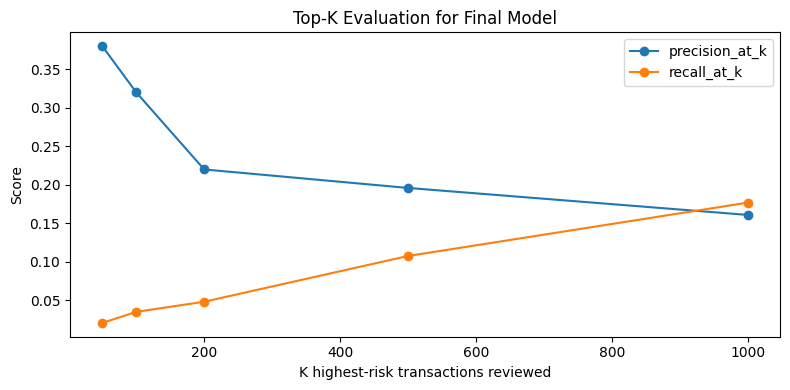

Saved: /home/acer/dev/aml-graph-dm/reports/figures/top_k_evaluation_node2vec.png


In [9]:
display(topk_eval)

ax = topk_eval.plot(kind="line", x="k", y=["precision_at_k", "recall_at_k"], marker="o", figsize=(8, 4))
ax.set_title("Top-K Evaluation for Final Model")
ax.set_xlabel("K highest-risk transactions reviewed")
ax.set_ylabel("Score")
plt.tight_layout()

out_path = FIGURES_DIR / "top_k_evaluation_node2vec.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## 7. Confusion matrix

The tuned threshold is a high-precision mode. Use the threshold table together with this confusion matrix.

,predicted_normal,predicted_laundering
Unnamed: 0,,
actual_normal,398614,476
actual_laundering,800,110


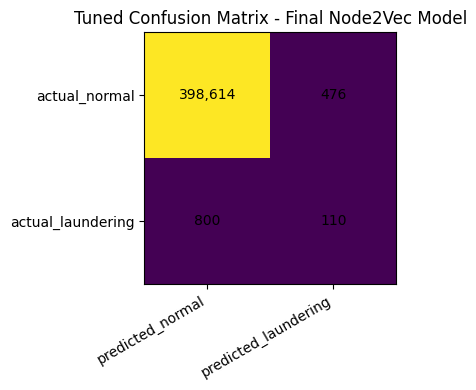

Saved: /home/acer/dev/aml-graph-dm/reports/figures/confusion_matrix_tuned_node2vec.png


In [10]:
cm = confusion_matrix_df.copy()
if "Unnamed: 0" in cm.columns:
    cm = cm.set_index("Unnamed: 0")

display(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm.values)
plt.title("Tuned Confusion Matrix - Final Node2Vec Model")
plt.xticks(range(len(cm.columns)), cm.columns, rotation=30, ha="right")
plt.yticks(range(len(cm.index)), cm.index)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{int(cm.values[i, j]):,}", ha="center", va="center")
plt.tight_layout()

out_path = FIGURES_DIR / "confusion_matrix_tuned_node2vec.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## Additional visual: Threshold-search curve

This shows the precision/recall trade-off as the decision threshold changes. It is useful for explaining why the dashboard keeps a threshold slider instead of hard-coding a single cutoff.

Loaded threshold_search_table_node2vec_final.csv from /home/acer/dev/aml-graph-dm/reports/tables/threshold_search_table_node2vec_final.csv


,threshold,f1,precision,recall,alert_count
0,0.01,0.032373,0.016669,0.559471,7619
1,0.02,0.038776,0.020120,0.533040,6014
2,0.03,0.042367,0.022099,0.511013,5249
3,0.04,0.045912,0.024056,0.502203,4739
4,0.05,0.047733,0.025103,0.484581,4382


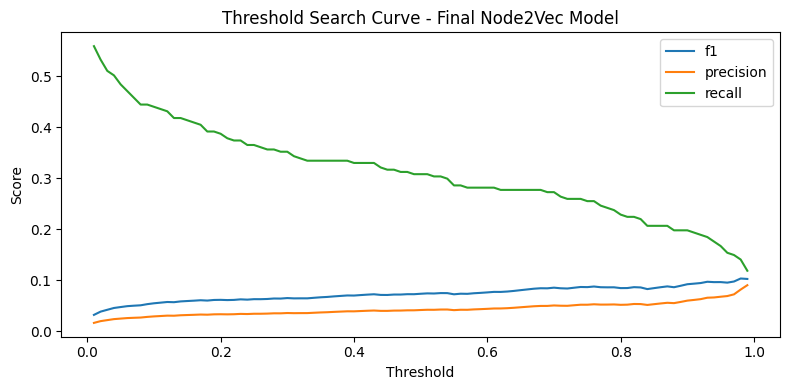

Saved: /home/acer/dev/aml-graph-dm/reports/figures/threshold_search_curve_node2vec.png


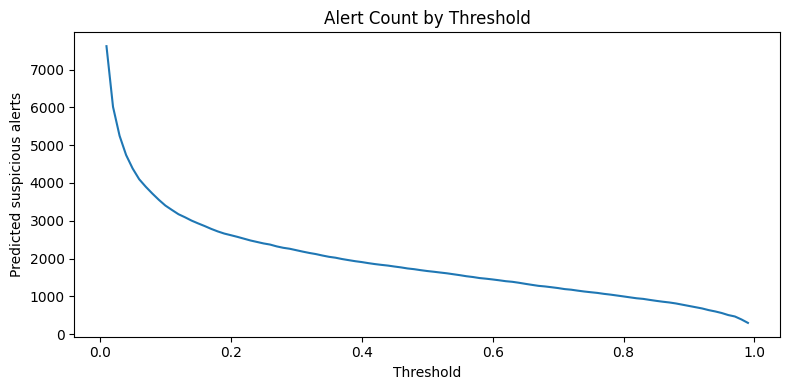

Saved: /home/acer/dev/aml-graph-dm/reports/figures/threshold_alert_count_node2vec.png


In [11]:
threshold_search = read_table("threshold_search_table_node2vec_final.csv", [
    {"threshold":0.50, "f1":0.181235, "precision":0.123315, "recall":0.341758, "alert_count":2522},
    {"threshold":0.98, "f1":0.147059, "precision":0.187713, "recall":0.120879, "alert_count":586},
])

display(threshold_search.head())

ax = threshold_search.plot(kind="line", x="threshold", y=["f1", "precision", "recall"], figsize=(8, 4))
ax.set_title("Threshold Search Curve - Final Node2Vec Model")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
plt.tight_layout()

out_path = FIGURES_DIR / "threshold_search_curve_node2vec.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

ax = threshold_search.plot(kind="line", x="threshold", y="alert_count", legend=False, figsize=(8, 4))
ax.set_title("Alert Count by Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Predicted suspicious alerts")
plt.tight_layout()

out_path = FIGURES_DIR / "threshold_alert_count_node2vec.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## Additional visual: Top-K comparison before and after node2vec

This answers whether node2vec improves analyst-review quality. Higher Precision@K means investigators see more true laundering transactions among the top-ranked alerts.

Loaded top_k_evaluation_advanced_graph_neg100.csv from /home/acer/dev/aml-graph-dm/reports/tables/top_k_evaluation_advanced_graph_neg100.csv


,k,advanced_graph_precision_at_k,node2vec_precision_at_k,absolute_gain
0,50,0.220,0.380,0.160
1,100,0.180,0.320,0.140
2,200,0.140,0.220,0.080
3,500,0.162,0.196,0.034
4,1000,0.138,0.161,0.023


Saved: /home/acer/dev/aml-graph-dm/reports/tables/top_k_node2vec_vs_advanced_graph.csv


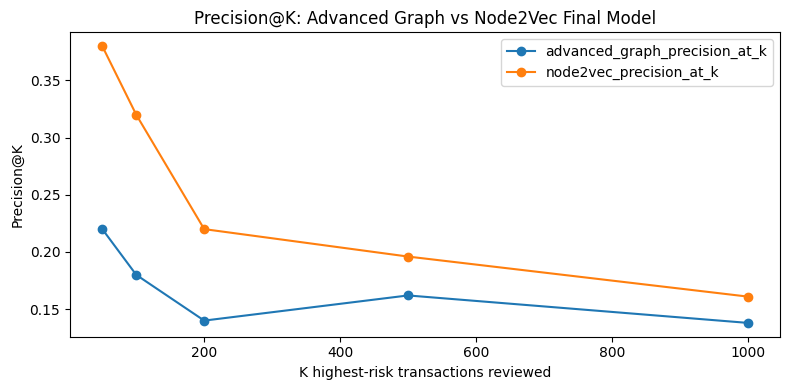

Saved: /home/acer/dev/aml-graph-dm/reports/figures/precision_at_k_node2vec_vs_advanced_graph.png


In [12]:
advanced_topk = read_table("top_k_evaluation_advanced_graph_neg100.csv", [
    {"k":50, "precision_at_k":0.220, "recall_at_k":0.012088},
    {"k":100, "precision_at_k":0.180, "recall_at_k":0.019780},
    {"k":200, "precision_at_k":0.140, "recall_at_k":0.030769},
    {"k":500, "precision_at_k":0.162, "recall_at_k":0.089011},
    {"k":1000, "precision_at_k":0.138, "recall_at_k":0.151648},
])

node2vec_topk = topk_eval.copy()

compare_topk = advanced_topk[["k", "precision_at_k"]].rename(columns={"precision_at_k":"advanced_graph_precision_at_k"})
compare_topk = compare_topk.merge(
    node2vec_topk[["k", "precision_at_k"]].rename(columns={"precision_at_k":"node2vec_precision_at_k"}),
    on="k",
    how="outer",
)

compare_topk["absolute_gain"] = compare_topk["node2vec_precision_at_k"] - compare_topk["advanced_graph_precision_at_k"]
display(compare_topk)
compare_topk.to_csv(TABLES_DIR / "top_k_node2vec_vs_advanced_graph.csv", index=False)
print("Saved:", TABLES_DIR / "top_k_node2vec_vs_advanced_graph.csv")

ax = compare_topk.plot(kind="line", x="k", y=["advanced_graph_precision_at_k", "node2vec_precision_at_k"], marker="o", figsize=(8, 4))
ax.set_title("Precision@K: Advanced Graph vs Node2Vec Final Model")
ax.set_xlabel("K highest-risk transactions reviewed")
ax.set_ylabel("Precision@K")
plt.tight_layout()

out_path = FIGURES_DIR / "precision_at_k_node2vec_vs_advanced_graph.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## Additional visual: Final metric comparison

This compact chart summarizes the final selected model's PR-AUC, F1, precision, and recall.

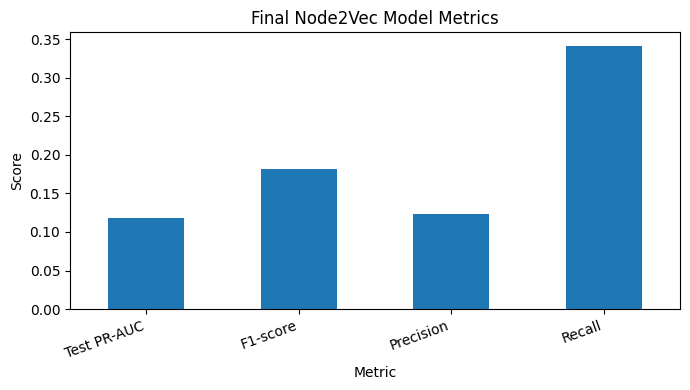

Saved: /home/acer/dev/aml-graph-dm/reports/figures/final_node2vec_metric_summary.png


In [13]:
final_metric_plot = final_summary[final_summary["metric"].isin(["Test PR-AUC", "F1-score", "Precision", "Recall"])].copy()

ax = final_metric_plot.plot(kind="bar", x="metric", y="value", legend=False, figsize=(7, 4))
ax.set_title("Final Node2Vec Model Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

out_path = FIGURES_DIR / "final_node2vec_metric_summary.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

## 8. Final interpretation for BAB IV

Report-ready conclusions:
- Graph features improve AML detection compared with raw transaction features.
- Advanced temporal graph features improve PR-AUC and F1 compared with historical-only graph features.
- Snapshot PageRank/community was tested but did not become the final configuration because it reduced the main metrics.
- Split-safe node2vec embeddings produced the strongest final result.
- The four-algorithm comparison satisfies the >3 algorithms bonus requirement.
- The final model is best interpreted as an analyst-prioritization model, not an autonomous legal decision system.

Final model statement:

`LightGBM + raw transaction features + historical graph features + rolling temporal graph features + centrality/motif-proxy features + split-safe node2vec embeddings`.

Final headline metrics:
- Test PR-AUC: 0.117686
- F1-score: 0.181235
- Precision: 0.123315
- Recall: 0.341758
- Precision@50: 0.380
- Precision@100: 0.320